In [1]:
#load data + recreate age_years column
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)

app = pd.read_csv('../Data/application_train.csv')

# Recreate age column from Phase 1
app['AGE_YEARS'] = abs(app['DAYS_BIRTH']) / 365

# Fix DAYS_EMPLOYED anomaly — 365243 means unemployed/retired, replace with NaN
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, np.nan)
app['EMPLOYMENT_YEARS'] = abs(app['DAYS_EMPLOYED']) / 365

print("Data loaded ✓")
print(f"Shape: {app.shape}")

Data loaded ✓
Shape: (307511, 124)


In [2]:
# This function plots any column split by default vs repaid
# We'll use it dozens of times

def plot_by_target(col, plot_type='hist', bins=30):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    defaulted = app[app['TARGET'] == 1][col].dropna()
    repaid    = app[app['TARGET'] == 0][col].dropna()
    
    if plot_type == 'hist':
        axes[0].hist(repaid,    bins=bins, color='#2ecc71', alpha=0.7, label='Repaid')
        axes[0].hist(defaulted, bins=bins, color='#e74c3c', alpha=0.7, label='Defaulted')
        axes[0].set_title(f'{col} — Distribution by Target')
        axes[0].legend()
    
    elif plot_type == 'bar':
        default_rate = app.groupby(col)['TARGET'].mean().sort_values(ascending=False)
        axes[0].bar(default_rate.index, default_rate.values, color='#e74c3c', alpha=0.8)
        axes[0].set_title(f'{col} — Default Rate by Category')
        axes[0].tick_params(axis='x', rotation=45)
    
    # Box plot on right
    app.boxplot(column=col if plot_type=='hist' else 'AGE_YEARS',
                by='TARGET', ax=axes[1])
    axes[1].set_title(f'{col} — Box Plot by Target')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary stats
    print(f"\n{col} — Mean by Target:")
    print(app.groupby('TARGET')[col].mean().round(2))

print("Helper function ready ✓")

Helper function ready ✓


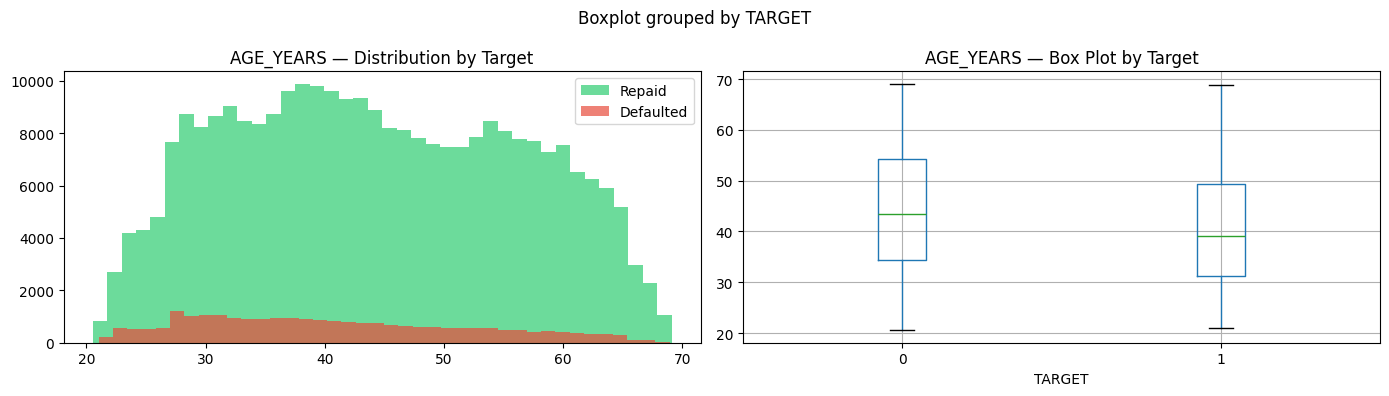


AGE_YEARS — Mean by Target:
TARGET
0    44.21
1    40.78
Name: AGE_YEARS, dtype: float64


C:\Users\mehak\AppData\Local\Temp\ipykernel_14812\356817400.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = app.groupby('AGE_GROUP')['TARGET'].mean() * 100


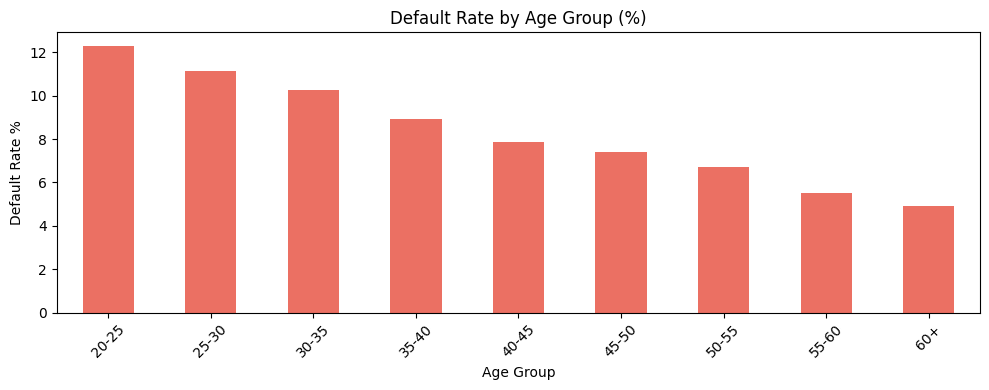


Default rate by age group:
AGE_GROUP
20-25    12.30
25-30    11.14
30-35    10.28
35-40     8.94
40-45     7.85
45-50     7.42
50-55     6.70
55-60     5.53
60+       4.92
Name: TARGET, dtype: float64


In [3]:
# Age vs Default
# Business question: Do younger people default more?

plot_by_target('AGE_YEARS', plot_type='hist', bins=40)

# Default rate by age group
app['AGE_GROUP'] = pd.cut(app['AGE_YEARS'], 
                           bins=[20, 25, 30, 35, 40, 45, 50, 55, 60, 70],
                           labels=['20-25','25-30','30-35','35-40',
                                   '40-45','45-50','50-55','55-60','60+'])

age_default = app.groupby('AGE_GROUP')['TARGET'].mean() * 100

plt.figure(figsize=(10, 4))
age_default.plot(kind='bar', color='#e74c3c', alpha=0.8)
plt.title('Default Rate by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Default Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nDefault rate by age group:")
print(age_default.round(2))

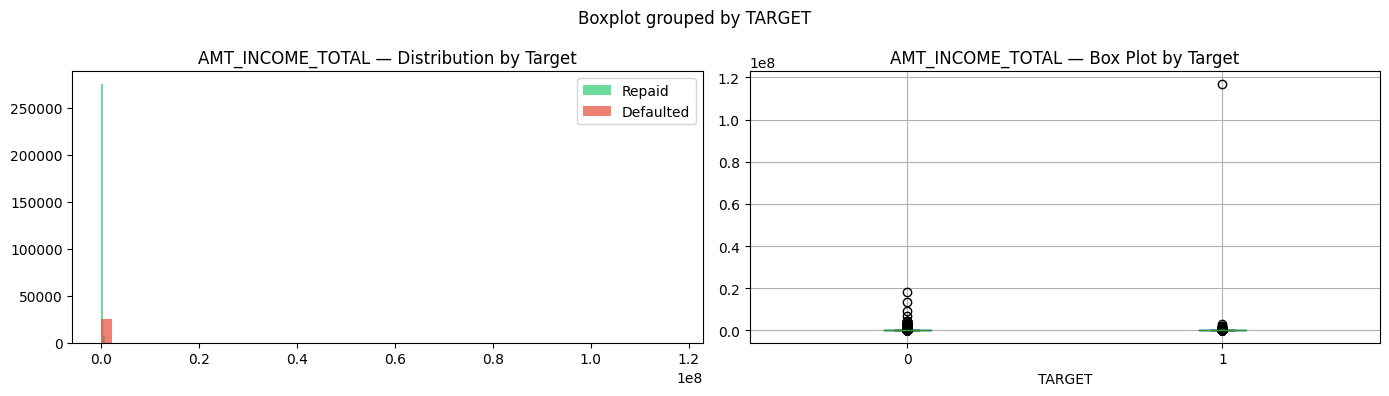


AMT_INCOME_TOTAL — Mean by Target:
TARGET
0    169077.72
1    165611.76
Name: AMT_INCOME_TOTAL, dtype: float64


C:\Users\mehak\AppData\Local\Temp\ipykernel_14812\3447204530.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = app.groupby('INCOME_GROUP')['TARGET'].mean() * 100


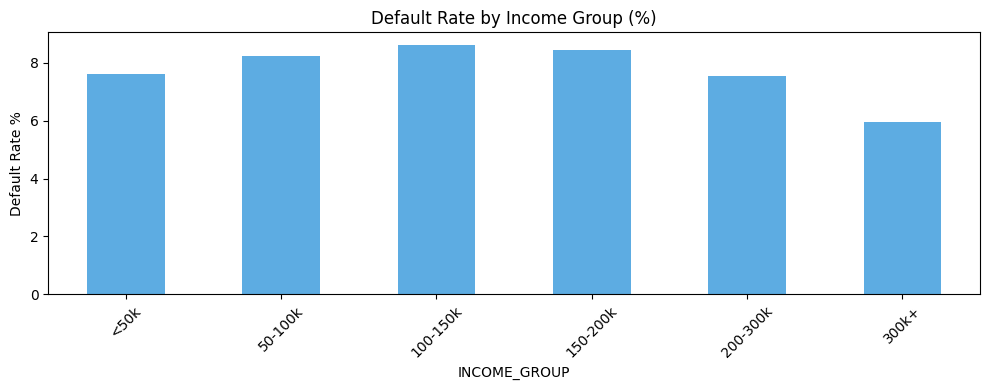


Default rate by income group:
INCOME_GROUP
<50k        7.59
50-100k     8.25
100-150k    8.62
150-200k    8.45
200-300k    7.55
300k+       5.95
Name: TARGET, dtype: float64


In [4]:
# Income vs Default
# Business question: Does income level predict default?

# Remove extreme outliers for visualization
app_income = app[app['AMT_INCOME_TOTAL'] < app['AMT_INCOME_TOTAL'].quantile(0.99)]

plot_by_target('AMT_INCOME_TOTAL', plot_type='hist', bins=50)

# Income buckets
app['INCOME_GROUP'] = pd.cut(app['AMT_INCOME_TOTAL'],
                              bins=[0, 50000, 100000, 150000, 200000, 300000, float('inf')],
                              labels=['<50k','50-100k','100-150k',
                                      '150-200k','200-300k','300k+'])

income_default = app.groupby('INCOME_GROUP')['TARGET'].mean() * 100

plt.figure(figsize=(10, 4))
income_default.plot(kind='bar', color='#3498db', alpha=0.8)
plt.title('Default Rate by Income Group (%)')
plt.ylabel('Default Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nDefault rate by income group:")
print(income_default.round(2))

Income percentiles:
0.25       112500.0
0.50       147150.0
0.75       202500.0
0.90       270000.0
0.95       337500.0
0.99       472500.0
1.00    117000000.0
Name: AMT_INCOME_TOTAL, dtype: float64

People earning above 1M: 250


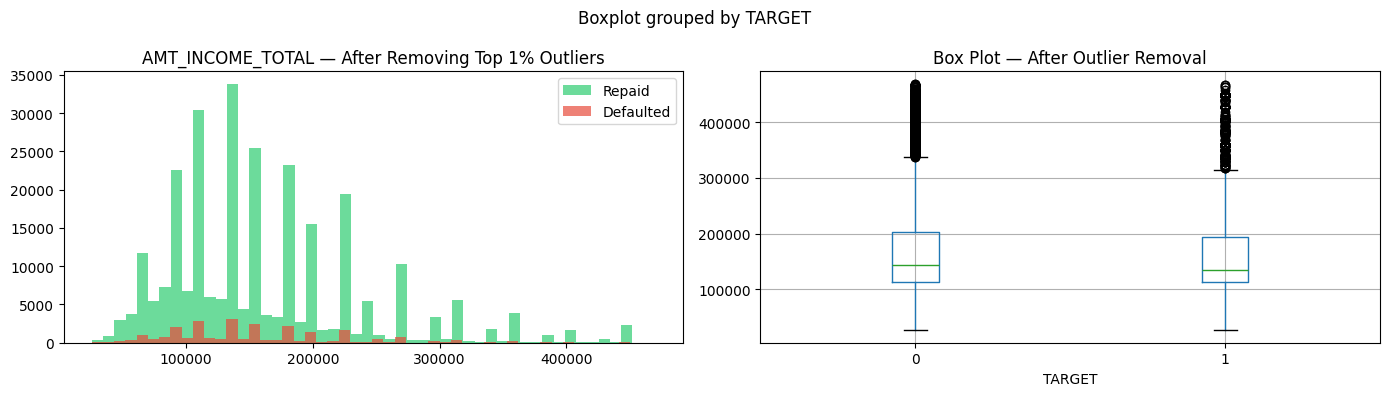

In [5]:
# Check how bad the outliers are
print("Income percentiles:")
print(app['AMT_INCOME_TOTAL'].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]))

# How many people earn above 1 million?
high_income = (app['AMT_INCOME_TOTAL'] > 1_000_000).sum()
print(f"\nPeople earning above 1M: {high_income}")

# Replot after capping at 99th percentile
cap = app['AMT_INCOME_TOTAL'].quantile(0.99)
app_clean = app[app['AMT_INCOME_TOTAL'] < cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

defaulted = app_clean[app_clean['TARGET'] == 1]['AMT_INCOME_TOTAL']
repaid    = app_clean[app_clean['TARGET'] == 0]['AMT_INCOME_TOTAL']

axes[0].hist(repaid,    bins=50, color='#2ecc71', alpha=0.7, label='Repaid')
axes[0].hist(defaulted, bins=50, color='#e74c3c', alpha=0.7, label='Defaulted')
axes[0].set_title('AMT_INCOME_TOTAL — After Removing Top 1% Outliers')
axes[0].legend()

app_clean.boxplot(column='AMT_INCOME_TOTAL', by='TARGET', ax=axes[1])
axes[1].set_title('Box Plot — After Outlier Removal')

plt.tight_layout()
plt.show()

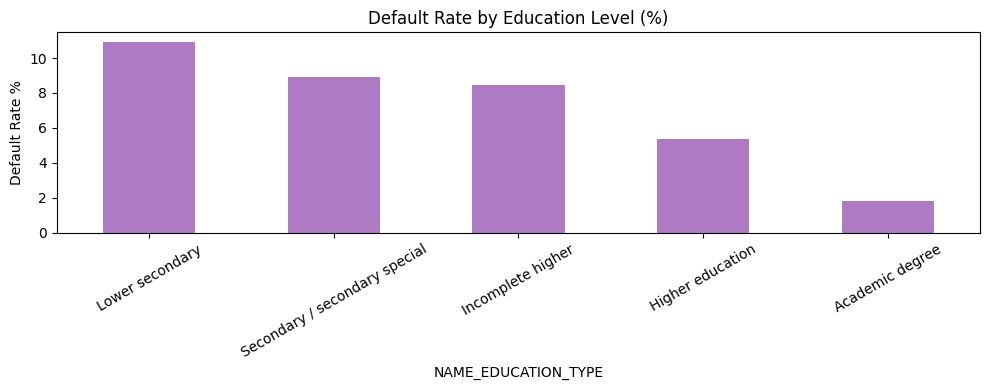


Default rate by education:
NAME_EDUCATION_TYPE
Lower secondary                  10.93
Secondary / secondary special     8.94
Incomplete higher                 8.48
Higher education                  5.36
Academic degree                   1.83
Name: TARGET, dtype: float64


In [6]:
# Education vs default
# Business question: Does education level affect default rate?

edu_default = app.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 4))
edu_default.plot(kind='bar', color='#9b59b6', alpha=0.8)
plt.title('Default Rate by Education Level (%)')
plt.ylabel('Default Rate %')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("\nDefault rate by education:")
print(edu_default.round(2))

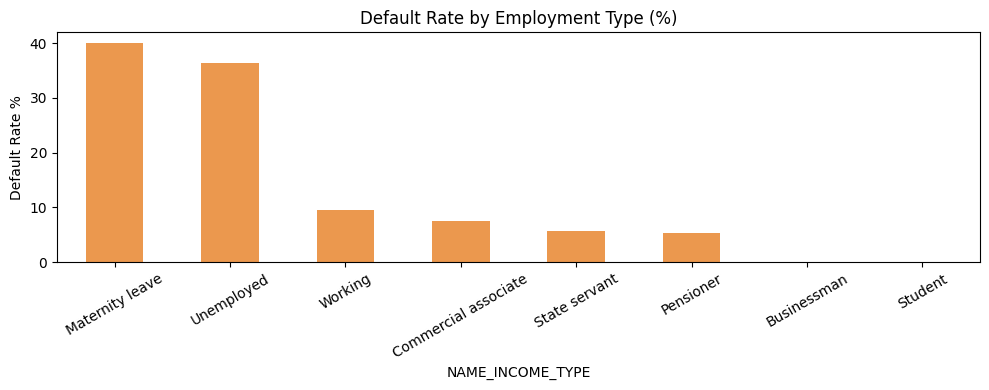


Default rate by employment type:
NAME_INCOME_TYPE
Maternity leave         40.00
Unemployed              36.36
Working                  9.59
Commercial associate     7.48
State servant            5.75
Pensioner                5.39
Businessman              0.00
Student                  0.00
Name: TARGET, dtype: float64


In [7]:
#Employment type vs default
# Business question: Which job types are riskiest?

emp_default = app.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 4))
emp_default.plot(kind='bar', color='#e67e22', alpha=0.8)
plt.title('Default Rate by Employment Type (%)')
plt.ylabel('Default Rate %')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("\nDefault rate by employment type:")
print(emp_default.round(2))

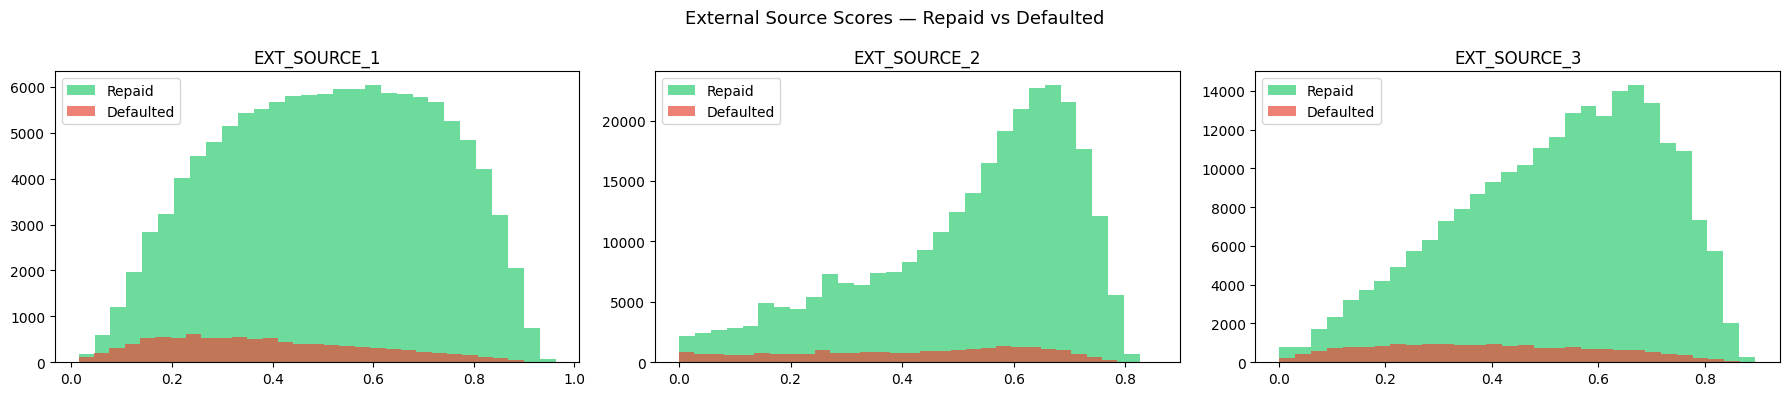

EXT_SOURCE_1 correlation with TARGET: -0.1553
EXT_SOURCE_2 correlation with TARGET: -0.1605
EXT_SOURCE_3 correlation with TARGET: -0.1789


In [8]:
# EXT_SOURCE scores (most important features)
# Business question: How predictive are the external credit scores?
# EXT_SOURCE_1, 2, 3 are scores from external credit bureaus
# These are typically the strongest predictors in this dataset

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    defaulted = app[app['TARGET'] == 1][col].dropna()
    repaid    = app[app['TARGET'] == 0][col].dropna()
    
    axes[i].hist(repaid,    bins=30, color='#2ecc71', alpha=0.7, label='Repaid')
    axes[i].hist(defaulted, bins=30, color='#e74c3c', alpha=0.7, label='Defaulted')
    axes[i].set_title(f'{col}')
    axes[i].legend()

plt.suptitle('External Source Scores — Repaid vs Defaulted', fontsize=13)
plt.tight_layout()
plt.show()

# Correlation with target
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    corr = app[col].corr(app['TARGET'])
    print(f"{col} correlation with TARGET: {corr:.4f}")

In [9]:
# Add this to your notebook now
app['EXT_SOURCE_MEAN'] = app[['EXT_SOURCE_1', 
                               'EXT_SOURCE_2', 
                               'EXT_SOURCE_3']].mean(axis=1)

app['EXT_SOURCE_MIN']  = app[['EXT_SOURCE_1', 
                               'EXT_SOURCE_2', 
                               'EXT_SOURCE_3']].min(axis=1)

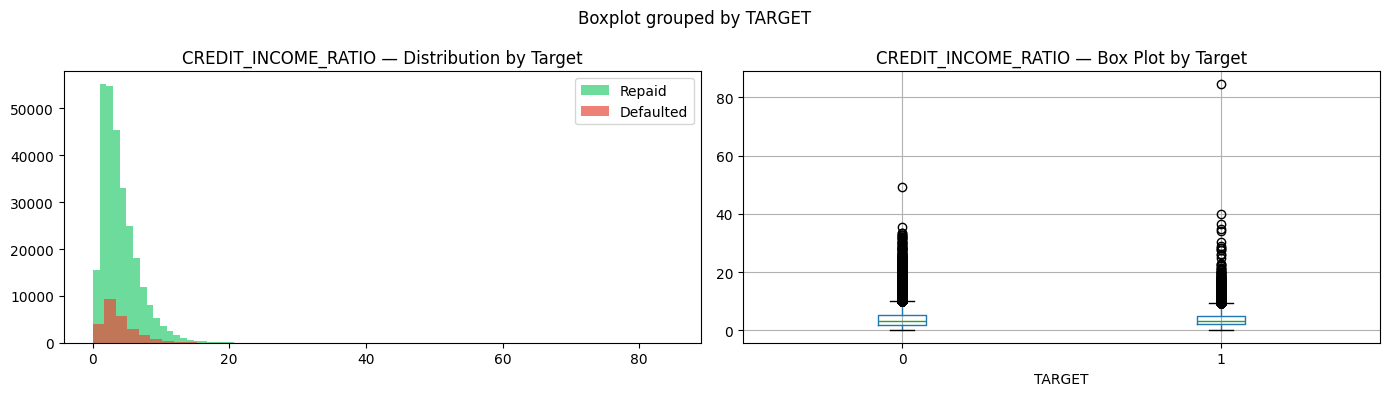


CREDIT_INCOME_RATIO — Mean by Target:
TARGET
0    3.96
1    3.89
Name: CREDIT_INCOME_RATIO, dtype: float64

Credit-to-Income ratio — Mean by Target:
TARGET
0    3.964
1    3.887
Name: CREDIT_INCOME_RATIO, dtype: float64

Annuity-to-Income ratio — Mean by Target:
TARGET
0    0.181
1    0.185
Name: ANNUITY_INCOME_RATIO, dtype: float64


In [10]:
# Loan amount vs income ratio
# Business question: Do people who borrow more than they earn default more?
# This is a feature we CREATE — called credit-to-income ratio

app['CREDIT_INCOME_RATIO'] = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']
app['ANNUITY_INCOME_RATIO'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']

plot_by_target('CREDIT_INCOME_RATIO', plot_type='hist', bins=50)

print("\nCredit-to-Income ratio — Mean by Target:")
print(app.groupby('TARGET')['CREDIT_INCOME_RATIO'].mean().round(3))

print("\nAnnuity-to-Income ratio — Mean by Target:")
print(app.groupby('TARGET')['ANNUITY_INCOME_RATIO'].mean().round(3))

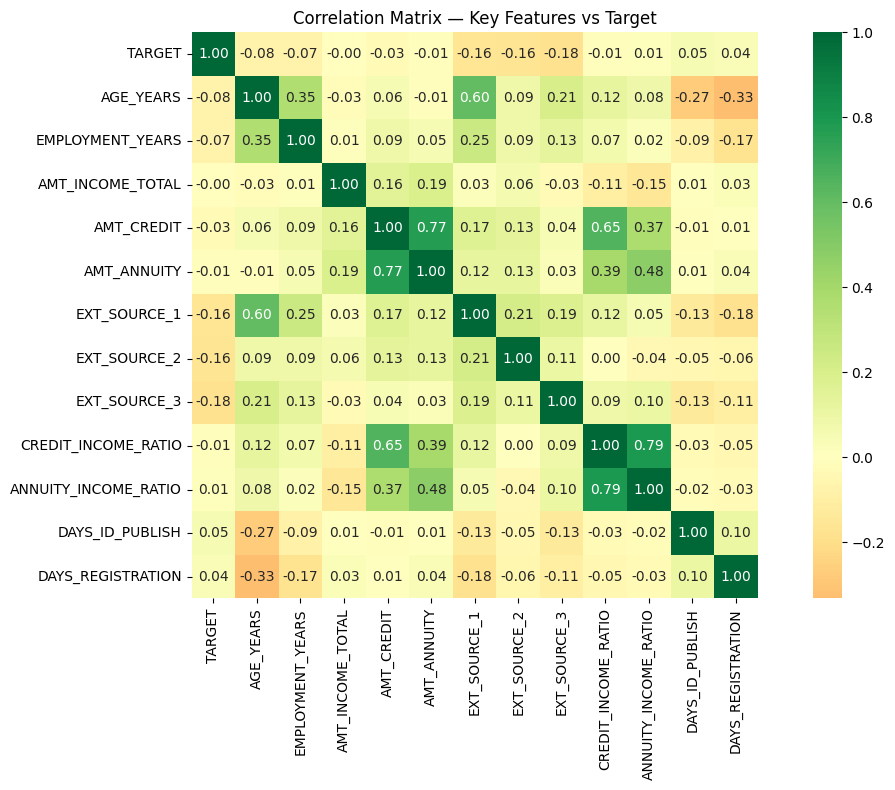


Features most correlated with default (TARGET):
EXT_SOURCE_3           -0.1789
EXT_SOURCE_2           -0.1605
EXT_SOURCE_1           -0.1553
AGE_YEARS              -0.0782
EMPLOYMENT_YEARS       -0.0750
AMT_CREDIT             -0.0304
AMT_ANNUITY            -0.0128
CREDIT_INCOME_RATIO    -0.0077
AMT_INCOME_TOTAL       -0.0040
ANNUITY_INCOME_RATIO    0.0143
DAYS_REGISTRATION       0.0420
DAYS_ID_PUBLISH         0.0515
Name: TARGET, dtype: float64


In [11]:
# Correlation heatmap(numerical features)
# Which numerical features correlate most with TARGET?

# Select key numerical columns only
key_cols = [
    'TARGET', 'AGE_YEARS', 'EMPLOYMENT_YEARS',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
    'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION'
]

corr_matrix = app[key_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            square=True)
plt.title('Correlation Matrix — Key Features vs Target')
plt.tight_layout()
plt.show()

# Print top correlations with TARGET specifically
target_corr = corr_matrix['TARGET'].drop('TARGET').sort_values()
print("\nFeatures most correlated with default (TARGET):")
print(target_corr.round(4))

Default rate by gender:
CODE_GENDER
F       7.00
M      10.14
XNA     0.00
Name: TARGET, dtype: float64


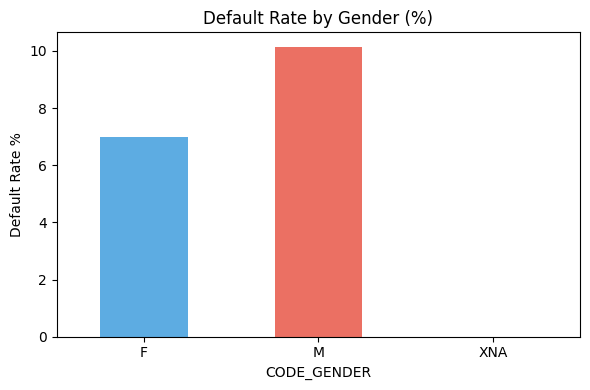

In [12]:
# Gender vs default
# Quick check — does gender matter?

gender_default = app.groupby('CODE_GENDER')['TARGET'].mean() * 100
print("Default rate by gender:")
print(gender_default.round(2))

plt.figure(figsize=(6, 4))
gender_default.plot(kind='bar', color=['#3498db', '#e74c3c'], alpha=0.8)
plt.title('Default Rate by Gender (%)')
plt.ylabel('Default Rate %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
print("""
=== EDA KEY FINDINGS ===

1. CLASS IMBALANCE   : ~8% default rate — need SMOTE or class weights in modeling

2. AGE              : Younger applicants (20-30) default more
                      Older applicants (50+) are lower risk

3. EXT_SOURCE       : Strongest predictors — lower score = higher default
                      EXT_SOURCE_2 has highest correlation with target

4. INCOME           : Lower income groups default slightly more
                      But ratio to loan amount matters more than raw income

5. EMPLOYMENT       : Unemployed/maternity leave = highest risk
                      Pensioners = lowest risk

6. ENGINEERED COLS  : CREDIT_INCOME_RATIO and ANNUITY_INCOME_RATIO
                      both show clear separation between defaulters/repayers

7. DAYS_EMPLOYED    : Had anomaly value 365243 — cleaned to NaN
""")


=== EDA KEY FINDINGS ===

1. CLASS IMBALANCE   : ~8% default rate — need SMOTE or class weights in modeling

2. AGE              : Younger applicants (20-30) default more
                      Older applicants (50+) are lower risk

3. EXT_SOURCE       : Strongest predictors — lower score = higher default
                      EXT_SOURCE_2 has highest correlation with target

4. INCOME           : Lower income groups default slightly more
                      But ratio to loan amount matters more than raw income

5. EMPLOYMENT       : Unemployed/maternity leave = highest risk
                      Pensioners = lowest risk

6. ENGINEERED COLS  : CREDIT_INCOME_RATIO and ANNUITY_INCOME_RATIO
                      both show clear separation between defaulters/repayers

7. DAYS_EMPLOYED    : Had anomaly value 365243 — cleaned to NaN

